In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Importing libraries

In [2]:
#importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV,KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

# Preparing dataset and features

In [3]:
# Loading the dataset and  defining features
df = pd.read_csv("https://raw.githubusercontent.com/9394113857/Data-Sets/f82f4f9ad22404bd244417b9ab4e5143a2804fcb/Housing.csv")


In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.dropna(inplace=True)

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)].copy()

df_cleaned["log_area"] = np.log(df_cleaned["area"])

features = ["log_area", "bedrooms", "bathrooms", "stories", "parking", "mainroad",
            "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea",
            "furnishingstatus"]
target = df_cleaned["price"]

X = df_cleaned[features]
y = target

# Visualizing data

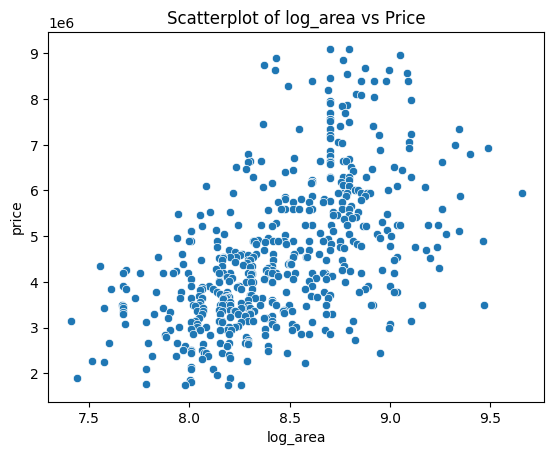

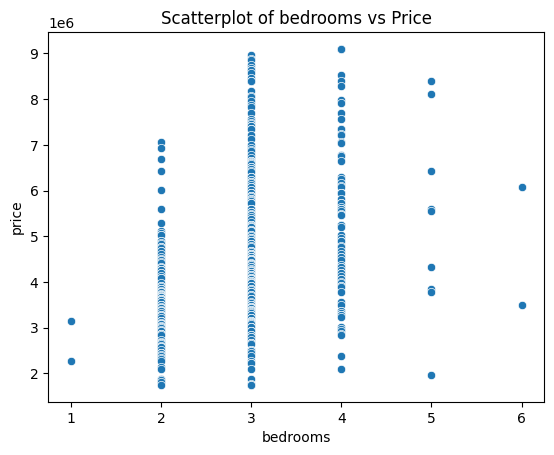

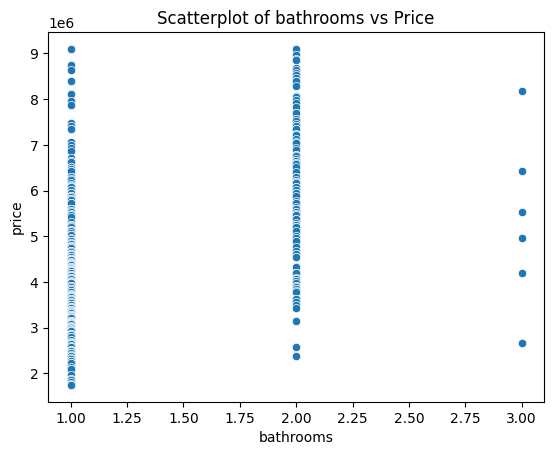

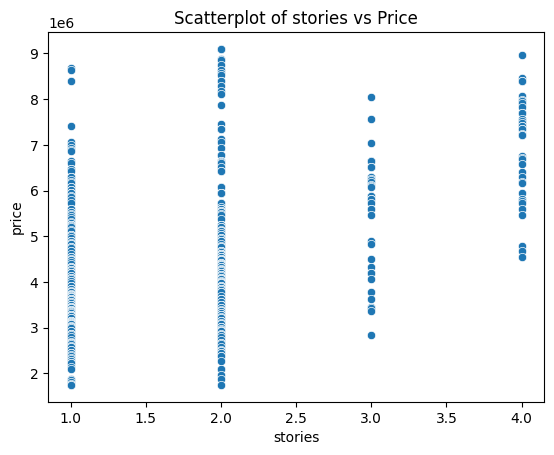

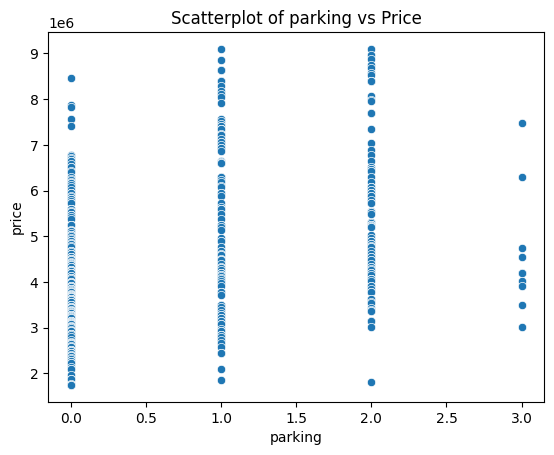

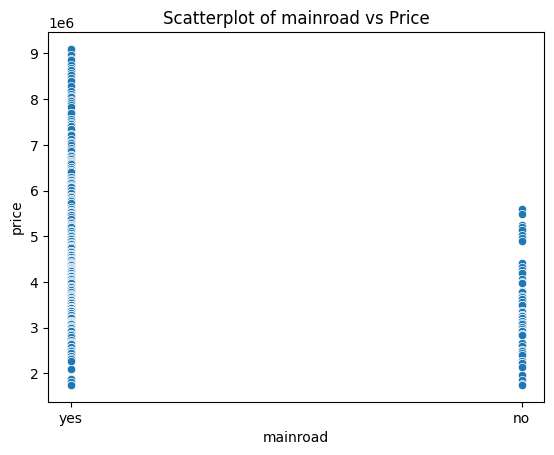

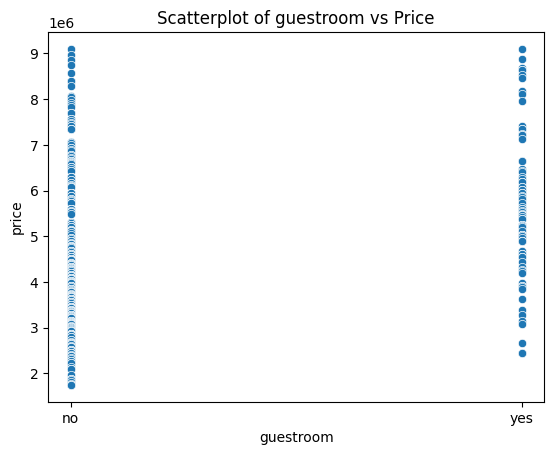

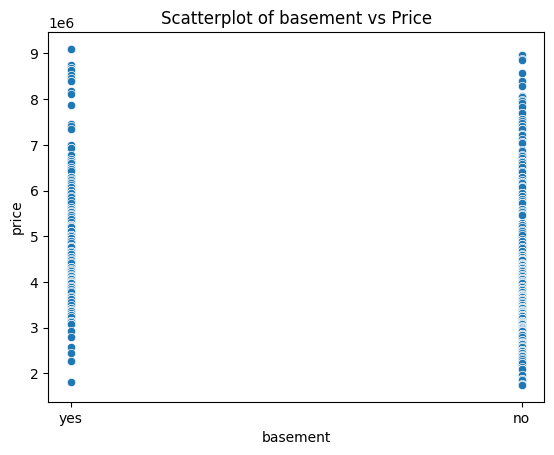

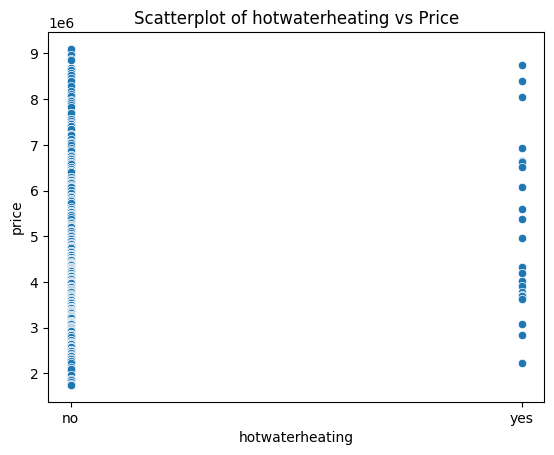

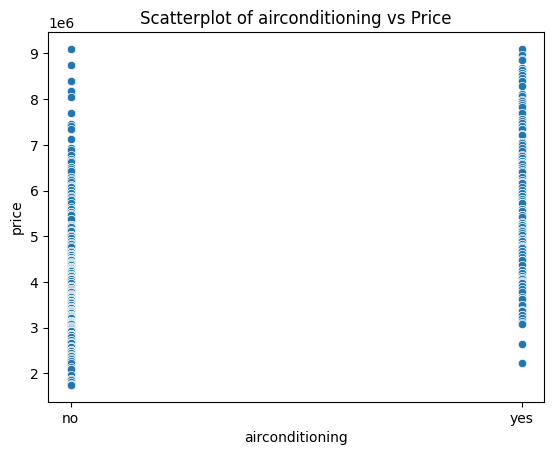

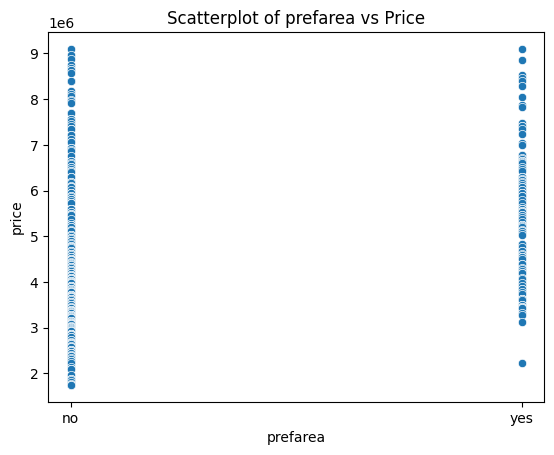

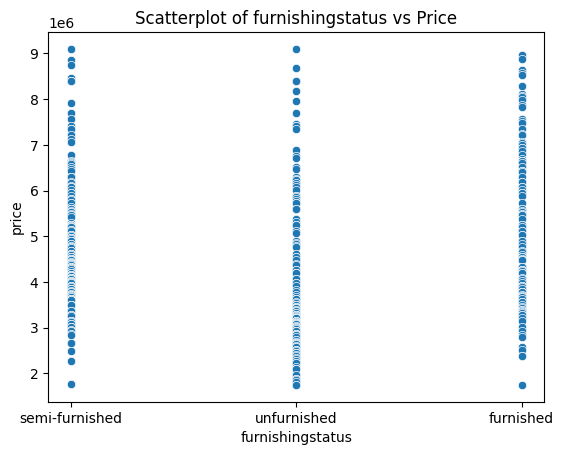

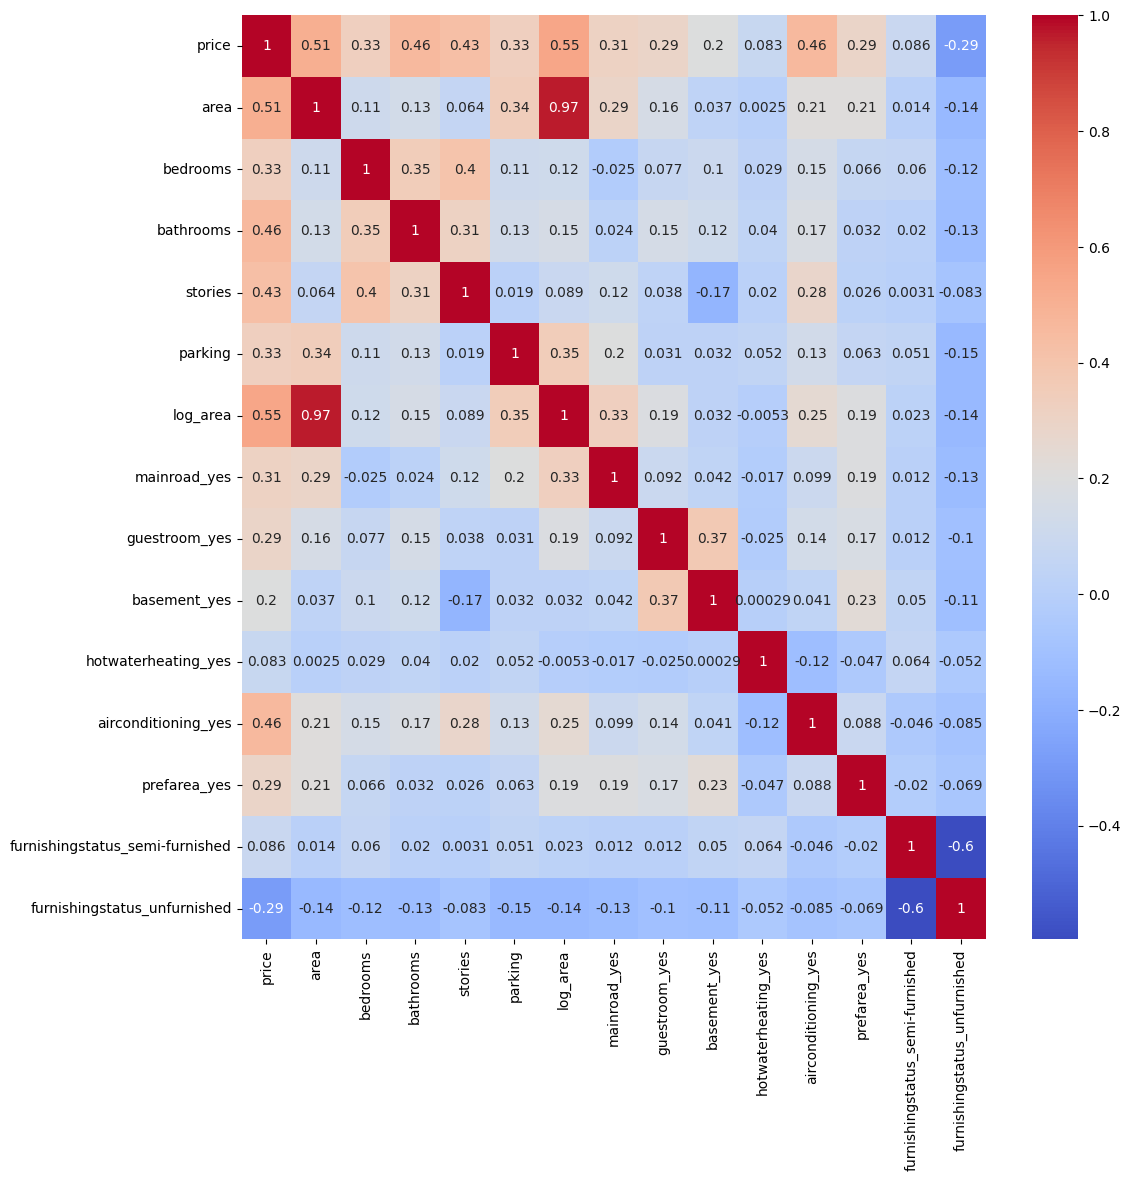

In [6]:
#visualizing data distribution
for feature in features:
    sns.scatterplot(data=df_cleaned, x=feature, y="price")
    plt.title(f"Scatterplot of {feature} vs Price")
    plt.show()

df_encoded = pd.get_dummies(df_cleaned, drop_first=True)
correlation_matrix = df_encoded.corr()
plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=True)
plt.show()

# Making model

In [7]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["log_area", "bathrooms", "bedrooms", "stories",
                                   "parking"]),
        ("cat", OneHotEncoder(), ["mainroad","guestroom", "basement", "hotwaterheating", "airconditioning",
                                  "prefarea","furnishingstatus"]),
])

In [8]:
#creating pipeline
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", ElasticNet(max_iter=10000))
])

In [9]:
# setting up Hyperparameter grid and K-fold
param_grid = {
    "regressor__alpha": [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    "regressor__l1_ratio": [0.1, 0.5, 0.7, 1]  # Mix between Lasso (1) and Ridge (0)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform grid search on the entire dataset
grid_search = GridSearchCV(pipeline, param_grid, cv=kf)
grid_search.fit(X, y)

# Get the best model and hyperparameters
print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Best score (neg MSE): {grid_search.best_score_}")

# Use the best model for evaluation
best_model = grid_search.best_estimator_

Best hyperparameters: {'regressor__alpha': 0.1, 'regressor__l1_ratio': 0.7}
Best score (neg MSE): 0.6475973570557463


In [10]:
#creating lists to later store the metrics
mse_list = []
r2_list = []
mae_list = []

In [11]:
# Cross-validation with the best model
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]  # Use .iloc for DataFrames
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = best_model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse_list.append(mean_squared_error(y_test, y_pred))
    r2_list.append(r2_score(y_test, y_pred))
    mae_list.append(mean_absolute_error(y_test, y_pred))

    print(f"Fold {fold + 1}:")
    print(f"  MSE: {mse_list[-1]}")
    print(f"  R2: {r2_list[-1]}")
    print(f"  MAE: {mae_list[-1]}")

Fold 1:
  MSE: 1132651543185.6826
  R2: 0.672891749737126
  MAE: 777655.6744738871
Fold 2:
  MSE: 1167555734965.3193
  R2: 0.5906858622928098
  MAE: 853299.9473045002
Fold 3:
  MSE: 572032298019.7185
  R2: 0.5966517589387437
  MAE: 623357.421899245
Fold 4:
  MSE: 829541219838.8613
  R2: 0.6591811459422124
  MAE: 653965.4644581196
Fold 5:
  MSE: 671739315700.9242
  R2: 0.7185762683678392
  MAE: 605614.9439736459


# Results

In [12]:
#Average results of the model
average_mse = np.mean(mse_list)
average_r2 = np.mean(r2_list)
average_mae = np.mean(mae_list)

print("\nCross-Validation Results:")
print(f"Average MSE: {average_mse}")
print(f"Average R2: {average_r2}")
print(f"Average MAE: {average_mae}")


Cross-Validation Results:
Average MSE: 874704022342.1013
Average R2: 0.6475973570557463
Average MAE: 702778.6904218795
